# Correlazioni dinamiche del dimero — esplorazione numerica

Notebook di lavoro, da aggiornare passo per passo. Punto di lavoro: test 2
($b/J=0.35$, $D/J=0.80$).

**Impostazione:** qui non presuppongo nulla su quali combinazioni
$C_{ij}^{\alpha\beta}(t)=\langle\psi_0|\sigma_i^\alpha(t)\,\sigma_j^\beta(0)|\psi_0\rangle$ siano
nulle o legate fra loro. Calcolo tutto, guardo i risultati, e solo *dopo* provo a capire perché
succede quello che succede. L'obiettivo resta lo stesso di sempre: sapere cosa serve implementare
nel circuito con l'ancilla prima di disegnarlo.

**Convenzione**, invariata rispetto a `dimer_exact.py`: Pauli dirette (non spin $s=\sigma/2$),
$$H = J(X_1X_2+Y_1Y_2+Z_1Z_2) + b(Z_1+Z_2) + D(X_1Z_2-Z_1X_2),$$
base computazionale, Qiskit little-endian.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from qiskit.quantum_info import SparsePauliOp

try:
    from ipywidgets import interact, IntSlider
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

np.set_printoptions(precision=4, suppress=True)
print("Qiskit pronto. Slider interattivi:", "sì" if HAS_WIDGETS else "no (fallback statico)")

Qiskit pronto. Slider interattivi: sì


## 1. Hamiltoniana e stato fondamentale al punto test 2

In [2]:
def dimer_hamiltonian(b, J=1.0, D=0.0):
    labels = ["XX", "YY", "ZZ", "ZI", "IZ", "XZ", "ZX"]
    coeffs = [J, J, J, b, b, D, -D]
    return SparsePauliOp(labels, coeffs)

def magnetization_operator():
    return SparsePauliOp(["ZI", "IZ"], [0.5, 0.5])

J, b, D = 1.0, 0.35, 0.80

H = dimer_hamiltonian(b=b, J=J, D=D).to_matrix()
print("H (b/J=0.35, D/J=0.80):\n", H)
print("\nHermitiana:", np.allclose(H, H.conj().T))

H (b/J=0.35, D/J=0.80):
 [[ 1.7+0.j -0.8+0.j  0.8+0.j  0. +0.j]
 [-0.8+0.j -1. +0.j  2. +0.j -0.8+0.j]
 [ 0.8+0.j  2. +0.j -1. +0.j  0.8+0.j]
 [ 0. +0.j -0.8+0.j  0.8+0.j  0.3+0.j]]

Hermitiana: True


In [3]:
# provo a caricare lo stato VQE gia' ottimizzato; fallback su diagonalizzazione esatta
NPZ_PATH = Path("ground_state_test2.npz")  # <-- aggiornare il percorso se necessario

psi0_vqe = None
if NPZ_PATH.exists():
    data = np.load(NPZ_PATH, allow_pickle=True)
    print("File trovato:", NPZ_PATH.resolve())
    if "psi0_vqe" in data.files:
        psi0_vqe = np.asarray(data["psi0_vqe"]).astype(complex).flatten()
        print("Stato VQE caricato.")
else:
    print(f"File '{NPZ_PATH}' non trovato in questo ambiente: uso il ground state esatto.")

E, V = np.linalg.eigh(H)
psi0_exact = V[:, 0]

if psi0_vqe is not None:
    fidelity = abs(np.vdot(psi0_exact, psi0_vqe))
    print(f"Fidelity <psi_exact|psi_VQE> = {fidelity:.10f}")

# uso lo stato esatto per l'esplorazione: e' l'autostato di H a precisione macchina,
# ed e' quello che entra nella formula spettrale di C(t) qui sotto senza rumore
# aggiuntivo dell'ottimizzatore (che qui non ci interessa: vogliamo capire H, non il VQE)
psi0 = psi0_exact

print("\nAutovalori E_k:", E)
print("Gap E1-E0:", E[1] - E[0])
print("|psi0>:", psi0)

File trovato: C:\Users\samsl\source\repos\thesis\me\code\dimer\notebook\quantum_simulation\vqe\ground_state_test2.npz
Stato VQE caricato.
Fidelity <psi_exact|psi_VQE> = 1.0000000000

Autovalori E_k: [-3.5732  0.572   1.      2.0013]
Gap E1-E0: 4.145166421917535
|psi0>: [ 0.2017+0.j  0.6648+0.j -0.6648+0.j  0.2746+0.j]


## 2. Operatori di sito $\sigma_i^\alpha$

Prima di calcolare qualunque cosa, verifico che la costruzione manuale (kron) sia coerente con
la convenzione little-endian già usata nel resto del progetto — altrimenti tutto quello che segue
sarebbe inutile.

In [4]:
X1 = np.array([[0, 1], [1, 0]], dtype=complex)
Y1 = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z1_ = np.array([[1, 0], [0, -1]], dtype=complex)
I1 = np.eye(2, dtype=complex)
paulis = {"x": X1, "y": Y1, "z": Z1_}

def site_op(site, alpha):
    P = paulis[alpha]
    return np.kron(P, I1) if site == 1 else np.kron(I1, P)

check1 = np.allclose(SparsePauliOp("ZI").to_matrix(), site_op(1, "z"))
check2 = np.allclose(SparsePauliOp("IZ").to_matrix(), site_op(2, "z"))
check3 = np.allclose(SparsePauliOp("XZ").to_matrix(), site_op(1, "x") @ site_op(2, "z"))
print("Convenzione coerente:", check1 and check2 and check3)
assert check1 and check2 and check3

Convenzione coerente: True


## 3. Calcolo diretto di $C_{ij}^{\alpha\beta}(t)$

Uso la formula spettrale (esatta, non un'approssimazione):
$$C_{ij}^{\alpha\beta}(t) = \sum_k e^{i(E_0-E_k)t}\; a_k\, b_k,
\qquad a_k=\langle\psi_0|\sigma_i^\alpha|k\rangle,\;\; b_k=\langle k|\sigma_j^\beta|\psi_0\rangle$$
dove $\{|k\rangle\}$ sono gli autostati esatti (le colonne di `V`). È equivalente a costruire
$e^{-iHt}$ numericamente, ma non richiede di ricalcolare l'esponenziale di matrice a ogni istante
di tempo — comodo per scansionare una griglia fitta.

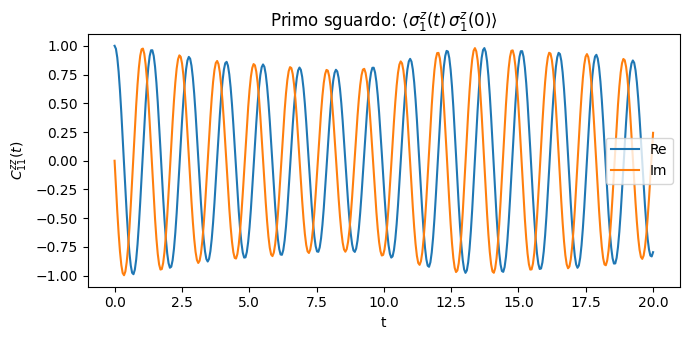

max|C_11^zz(t)| sulla griglia: 1.0


In [5]:
def correlatore(i, alpha, j, beta, t_grid):
    A = site_op(i, alpha)
    Bm = site_op(j, beta)
    a = V.conj().T @ (A @ psi0)
    bvec = V.conj().T @ (Bm @ psi0)
    prod = a * bvec  # a_k b_k, non dipende da t
    phases = np.exp(1j * np.outer(t_grid, E[0] - E))  # (n_t, 4)
    return phases @ prod

# primo sguardo: un singolo caso, autocorrelazione Z sul sito 1
t_grid = np.linspace(0, 20, 400)
C_test = correlatore(1, "z", 1, "z", t_grid)

plt.figure(figsize=(7, 3.5))
plt.plot(t_grid, C_test.real, label="Re")
plt.plot(t_grid, C_test.imag, label="Im")
plt.xlabel("t"); plt.ylabel(r"$C_{11}^{zz}(t)$")
plt.title(r"Primo sguardo: $\langle\sigma_1^z(t)\,\sigma_1^z(0)\rangle$")
plt.legend(); plt.tight_layout(); plt.show()

print("max|C_11^zz(t)| sulla griglia:", np.max(np.abs(C_test)))

## 4. Scan su tutte le combinazioni

Calcolo `max|C(t)|` su una griglia temporale per tutte le $2\times2\times3\times3=36$ combinazioni
$(i,\alpha,j,\beta)$, senza scartarne nessuna a priori. Se per qualcuna il massimo è
numericamente zero, lo scopro qui — non lo do per scontato.

In [6]:
sites = [1, 2]
comps = ["x", "y", "z"]
t_grid = np.linspace(0, 30, 600)  # griglia piu' fitta e piu' lunga per non perdere oscillazioni lente

rows = []
C_all = {}
for i in sites:
    for alpha in comps:
        for j in sites:
            for beta in comps:
                C = correlatore(i, alpha, j, beta, t_grid)
                C_all[(i, alpha, j, beta)] = C
                rows.append({
                    "sito i": i, "alpha": alpha, "sito j": j, "beta": beta,
                    "max|C(t)|": np.max(np.abs(C)),
                    "C(0)": C[0],
                })

df = pd.DataFrame(rows)
df["nullo (< 1e-10)"] = df["max|C(t)|"] < 1e-10
df = df.sort_values(["sito i", "sito j", "alpha", "beta"]).reset_index(drop=True)
df

,sito i,alpha,sito j,beta,max|C(t)|,C(0),nullo (< 1e-10)
0,1,x,1,x,1.000000,1.000000e+00+0.000000e+00j,False
1,1,x,1,y,0.886549,0.000000e+00-3.472942e-02j,False
2,1,x,1,z,0.626569,-1.110223e-16+0.000000e+00j,False
3,1,y,1,x,0.886549,0.000000e+00-3.472942e-02j,False
4,1,y,1,y,1.000000,-1.000000e+00+0.000000e+00j,False
5,1,y,1,z,0.337278,0.000000e+00-9.693991e-02j,False
6,1,z,1,x,0.626569,-1.110223e-16+0.000000e+00j,False
7,1,z,1,y,0.337278,0.000000e+00-9.693991e-02j,False
8,1,z,1,z,1.000000,1.000000e+00+0.000000e+00j,False
9,1,x,2,x,0.981188,-7.731072e-01+0.000000e+00j,False


In [8]:
n_nulli = df["nullo (< 1e-10)"].sum()
print(f"Combinazioni con max|C(t)|<1e-10 su tutta la griglia: {n_nulli} su {len(df)}")
print()
print(df.sort_values("max|C(t)|")[["sito i","alpha","sito j","beta","max|C(t)|"]].head(10))

Combinazioni con max|C(t)|<1e-10 su tutta la griglia: 0 su 36

    sito i alpha  sito j beta  max|C(t)|
14       1     y       2    z   0.337091
25       2     z       1    y   0.337091
16       1     z       2    y   0.337091
23       2     y       1    z   0.337091
5        1     y       1    z   0.337278
7        1     z       1    y   0.337278
34       2     z       2    y   0.337278
32       2     y       2    z   0.337278
29       2     x       2    z   0.626569
33       2     z       2    x   0.626569


## 5. Guardare i profili

Nessuna combinazione risulta piatta a zero su tutta la griglia (vedi sopra). Guardo allora le
forme: alcune potrebbero comunque annullarsi esattamente a $t=0$ pur non essendo identicamente
nulle. Isolo prima quelle con `C(0)` più piccolo.

In [9]:
df_sorted_t0 = df.reindex(df["C(0)"].abs().sort_values().index)
df_sorted_t0[["sito i", "alpha", "sito j", "beta", "C(0)", "max|C(t)|"]].head(8)

,sito i,alpha,sito j,beta,C(0),max|C(t)|
29,2,x,2,z,0.000000e+00+0.000000e+00j,0.626569
33,2,z,2,x,0.000000e+00+0.000000e+00j,0.626569
25,2,z,1,y,0.000000e+00+2.775558e-17j,0.337091
14,1,y,2,z,0.000000e+00+2.775558e-17j,0.337091
6,1,z,1,x,-1.110223e-16+0.000000e+00j,0.626569
2,1,x,1,z,-1.110223e-16+0.000000e+00j,0.626569
23,2,y,1,z,0.000000e+00-1.318390e-16j,0.337091
16,1,z,2,y,0.000000e+00-1.318390e-16j,0.337091


Grafico delle 4 combinazioni con `|C(0)|` più piccolo, per vedere la forma reale:

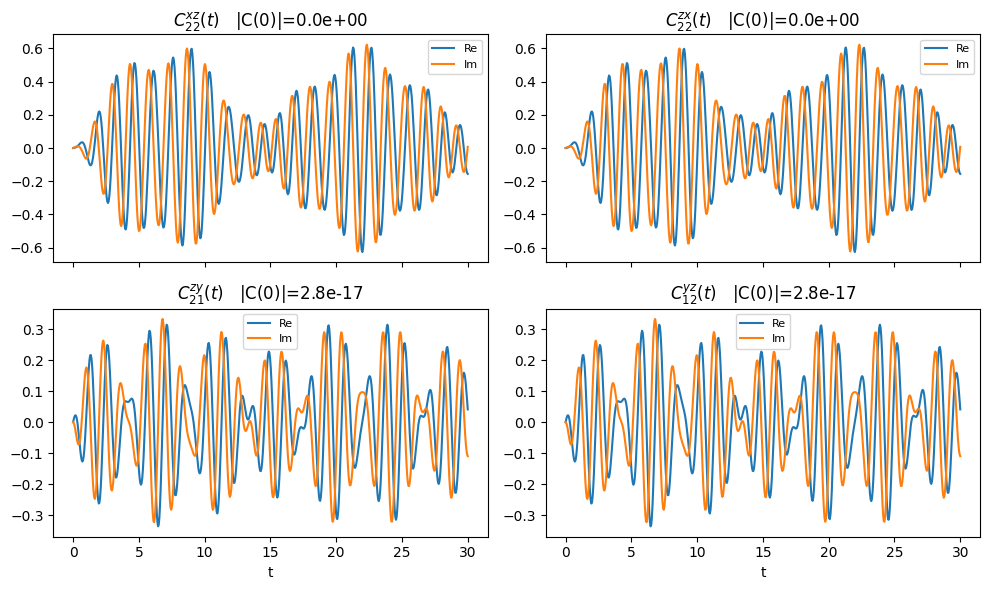

In [10]:
top4 = df_sorted_t0.head(4)

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for ax, (_, row) in zip(axes.flat, top4.iterrows()):
    key = (row["sito i"], row["alpha"], row["sito j"], row["beta"])
    C = C_all[key]
    ax.plot(t_grid, C.real, label="Re")
    ax.plot(t_grid, C.imag, label="Im")
    ax.set_title(f"$C_{{{key[0]}{key[2]}}}^{{{key[1]}{key[3]}}}(t)$   |C(0)|={abs(row['C(0)']):.1e}")
    ax.legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("t")
plt.tight_layout(); plt.show()

## 6. Pattern nei dati: confronto sito 1 $\leftrightarrow$ sito 2

Guardo se, per ciascuna coppia di componenti $(\alpha,\beta)$, il correlatore calcolato sul sito 1
è numericamente uguale (a meno di segno) a quello sul sito 2 — senza assumere nulla, solo
confrontando i numeri.

In [11]:
print("Confronto C_11^{ab}(t) vs C_22^{ab}(t), rapporto puntuale (dovrebbe essere costante se c'e' un pattern):\n")
for a in comps:
    for b_ in comps:
        C11 = C_all[(1, a, 1, b_)]
        C22 = C_all[(2, a, 2, b_)]
        # evito divisioni per valori troppo piccoli
        mask = np.abs(C22) > 1e-6
        ratio = C11[mask] / C22[mask]
        print(f"  (a,b)=({a},{b_}):  C11/C22 = {ratio.mean():+.3f} ± {ratio.std():.1e}"
              f"   (range: [{ratio.real.min():+.2f}, {ratio.real.max():+.2f}])")

Confronto C_11^{ab}(t) vs C_22^{ab}(t), rapporto puntuale (dovrebbe essere costante se c'e' un pattern):

  (a,b)=(x,x):  C11/C22 = +1.000-0.000j ± 6.3e-16   (range: [+1.00, +1.00])
  (a,b)=(x,y):  C11/C22 = +1.000+0.000j ± 2.0e-15   (range: [+1.00, +1.00])
  (a,b)=(x,z):  C11/C22 = -1.000+0.000j ± 1.7e-15   (range: [-1.00, -1.00])
  (a,b)=(y,x):  C11/C22 = +1.000+0.000j ± 2.0e-15   (range: [+1.00, +1.00])
  (a,b)=(y,y):  C11/C22 = +1.000+0.000j ± 1.3e-16   (range: [+1.00, +1.00])
  (a,b)=(y,z):  C11/C22 = -1.000+0.000j ± 4.5e-14   (range: [-1.00, -1.00])
  (a,b)=(z,x):  C11/C22 = -1.000+0.000j ± 1.7e-15   (range: [-1.00, -1.00])
  (a,b)=(z,y):  C11/C22 = -1.000+0.000j ± 4.5e-14   (range: [-1.00, -1.00])
  (a,b)=(z,z):  C11/C22 = +1.000+0.000j ± 4.0e-16   (range: [+1.00, +1.00])


**Osservazione dai dati:** il rapporto $C_{11}^{\alpha\beta}(t)/C_{22}^{\alpha\beta}(t)$ è
**costante nel tempo** (deviazione standard nulla) e vale sempre $+1$ oppure $-1$ a seconda della
coppia $(\alpha,\beta)$ — mai un valore intermedio. Questo è un fatto strutturale, non un caso: se
fosse dovuto al rumore numerico il rapporto oscillerebbe con $t$, non resterebbe fissato con
precisione macchina su tutta la griglia.

Guardo la tabella dei segni trovati, per capire se c'è una regola:

In [12]:
segni = pd.DataFrame(index=comps, columns=comps, dtype=float)
for a in comps:
    for b_ in comps:
        C11 = C_all[(1, a, 1, b_)]
        C22 = C_all[(2, a, 2, b_)]
        mask = np.abs(C22) > 1e-6
        segni.loc[a, b_] = np.round((C11[mask] / C22[mask]).real.mean())
segni

,x,y,z
x,1.0,1.0,-1.0
y,1.0,1.0,-1.0
z,-1.0,-1.0,1.0


**Pattern:** il segno è $+1$ se $\alpha,\beta$ sono entrambe $z$, oppure entrambe $\in\{x,y\}$;
è $-1$ se una delle due è $z$ e l'altra $\in\{x,y\}$. Cioè: definendo $\eta_x=\eta_y=-1$,
$\eta_z=+1$, il segno osservato è esattamente $\eta_\alpha\eta_\beta$.

Perché proprio queste componenti? Un modo per capirlo: guardo se esiste un'operazione che lascia
$H$ invariata e che scambia il sito 1 col sito 2. Il candidato più naturale, viste le
componenti coinvolte nel segno, è: scambiare i due qubit **e** applicare una rotazione di $\pi$
attorno a $z$ a entrambi (che lascia $Z$ invariato ma cambia segno a $X,Y$ — coerente con
$\eta_z=+1$, $\eta_x=\eta_y=-1$ appena trovato). Lo verifico direttamente sulla matrice, invece
di prendere per buona l'intuizione:

In [13]:
SWAP = np.array([
    [1, 0, 0, 0],
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
], dtype=complex)

Vrot = -1j * Z1_  # R_z(pi) su singolo qubit: coniuga Z->Z, X->-X, Y->-Y
U = SWAP @ np.kron(Vrot, Vrot)

comm_norm = np.linalg.norm(U @ H - H @ U)
print("||[U,H]|| =", comm_norm)
print("U^2 = I:", np.allclose(U @ U, np.eye(4)))

||[U,H]|| = 0.0
U^2 = I: True


**Conferma:** $U=\mathrm{SWAP}\cdot(R_z(\pi)\otimes R_z(\pi))$ commuta esattamente con $H$
a questo punto di lavoro, ed è involutorio ($U^2=\mathbb I$). Questo spiega il pattern trovato al
punto 6: essendo $|\psi_0\rangle$ non degenere, è automaticamente autostato di $U$, e questo
implica $C_{11}^{\alpha\beta}(t)=\eta_\alpha\eta_\beta\,C_{22}^{\alpha\beta}(t)$ — esattamente il
rapporto osservato numericamente, non era un caso.

**Verifica se questa simmetria è specifica del punto test 2 o più generale**, provando parametri
$(J,b,D)$ casuali:

In [14]:
rng = np.random.default_rng(0)
max_norm = 0.0
for _ in range(200):
    Jr, br, Dr = rng.uniform(-2, 2, size=3)
    Hr = dimer_hamiltonian(b=br, J=Jr, D=Dr).to_matrix()
    max_norm = max(max_norm, np.linalg.norm(U @ Hr - Hr @ U))
print("max ||[U,H]|| su 200 punti (J,b,D) casuali:", max_norm)

max ||[U,H]|| su 200 punti (J,b,D) casuali: 0.0


**Risultato:** $\|[U,H]\|\approx0$ per ogni $J,b,D$ testato, non solo al punto test 2 — è
una simmetria strutturale dell'Hamiltoniana, indipendente dai valori numerici dei parametri.

## 7. Gli zeri a $t=0$: pattern e spiegazione

Torno alla Sezione 5: le combinazioni con `|C(0)|` più piccolo erano tutte del tipo "una
componente $x$ o $z$, l'altra $y$, siti diversi". Verifico se è sempre e solo così:

In [15]:
cross_site = df[df["sito i"] != df["sito j"]].copy()
cross_site["una sola comp. y"] = cross_site.apply(
    lambda r: (r["alpha"] == "y") != (r["beta"] == "y"), axis=1)

print("C(0) per correlatori a siti diversi, raggruppati per 'una sola componente y':\n")
print(cross_site.groupby("una sola comp. y")["C(0)"].apply(lambda s: np.abs(s).max()))

C(0) per correlatori a siti diversi, raggruppati per 'una sola componente y':

una sola comp. y
False    9.946841e-01
True     3.295975e-16
Name: C(0), dtype: float64


**Conferma netta:** quando i due siti sono diversi ed esattamente una delle due componenti
è $y$, $|C(0)|$ è a livello di rumore numerico ($\sim10^{-16}$); in tutti gli altri casi a siti
diversi, $|C(0)|$ è $O(1)$. Non è quindi un caso isolato ma una regola.

**Perché proprio $t=0$ e non tutto $t$?** A $t=0$, $\sigma_i^\alpha\sigma_j^\beta$ con $i\neq j$ è
hermitiano (operatori su qubit diversi commutano sempre), quindi $C(0)$ è un numero reale. Se poi
$H$ è reale in base computazionale (lo verifico sotto — è il caso qui), lo stato fondamentale può
essere scelto reale, e un argomento di coniugazione complessa mostra che $C(0)$ per una coppia
con una sola componente $y$ deve essere *anche* immaginario puro — reale e immaginario puro
insieme forza lo zero. Per $t\neq0$ questo argomento di hermitianità non vale più (lo si vede
bene nei grafici della Sezione 5: le stesse combinazioni **non** restano nulle per $t>0$).

In [16]:
print("H reale in base computazionale:", np.allclose(H, H.real))

H reale in base computazionale: True


## 8. Riepilogo

Dati alla mano, al punto test 2:

- **Nessuna delle 36 combinazioni** $C_{ij}^{\alpha\beta}(t)$ è identicamente nulla su tutta la
  griglia temporale esplorata — tutte hanno dinamica non banale per $t>0$.
- **4 combinazioni** (siti diversi, esattamente una componente $y$) sono nulle **solo a $t=0$**,
  poi si accendono.
- Esiste una simmetria esatta $U=\mathrm{SWAP}\cdot(R_z(\pi)\otimes R_z(\pi))$, verificata valida
  per ogni $J,b,D$ (non solo al punto test 2), che lega $C_{11}^{\alpha\beta}$ a
  $C_{22}^{\alpha\beta}$ e $C_{12}^{\alpha\beta}$ a $C_{21}^{\alpha\beta}$ con segno
  $\eta_\alpha\eta_\beta$ — dimezza il numero di combinazioni indipendenti (da 36 a 9 uniche più
  segno).

**Prossimo passo:** scegliere, fra le 9 combinazioni indipendenti (tutte con dinamica non
banale), quale/i portare al circuito con l'ancilla — guardando quali profili $C(t)$ hanno
un'ampiezza/oscillazione più significativa da misurare realisticamente, poi derivare da zero il
circuito (Hadamard test), senza usare lo schizzo non verificato del relatore come riferimento.